# Cost to Serve: Multi-Bid Random Runs vs Single-Bid Baseline

Loads a CSV from `run_noisy_offer_experiment`, reads the single-bid baseline row (`sample=0,time=0`) if present, and compares random multi-bid samples against it.

In [1]:
using CSV
using DataFrames
using Statistics
using Plots

In [ ]:
# --- User inputs ---
csv_path = "../outputs/noisy_offer_results.csv"


"Random build_multi_bid_model vs build_single_bid_model"

In [9]:
df = CSV.read(csv_path, DataFrame)

normalize_colname(n) = begin
    s = String(n)
    s = replace(s, '\ufeff' => "")
    s = lowercase(strip(s))
    s = replace(s, r"[^a-z0-9]+" => "_")
    s = strip(s, '_')
    Symbol(s)
end

rename!(df, Dict(n => normalize_colname(n) for n in names(df)))

required_cols = (:sample, :time, :cost_to_serve)
present_cols = Set(Symbol.(names(df)))
missing_cols = filter(c -> !(c in present_cols), required_cols)
@assert isempty(missing_cols) "CSV is missing required columns: $(missing_cols). Found: $(names(df))"

baseline_rows = df[(df.sample .== 0) .& (df.time .== 0), :]
single_bid_cost_to_serve = nrow(baseline_rows) >= 1 ? baseline_rows.cost_to_serve[1] : missing
single_bid_ess_surplus = nrow(baseline_rows) >= 1  ? baseline_rows.ess_surplus[1] : missing

multi_df = df[df.sample .> 0, :]
@assert nrow(multi_df) > 0 "No multi-bid sample rows found (expected sample > 0)."

multi_cost_by_sample = combine(groupby(multi_df, :sample), :cost_to_serve => first => :multi_bid_cost_to_serve)
multi_ess_surplus = combine(groupby(multi_df, :sample), :ess_surplus => first => :multi_bid_ess_surplus)

sort!(multi_cost_by_sample, :sample)
println("Using single_bid_cost_to_serve = ", single_bid_cost_to_serve)
println("Using single_bid_ess_surplus = ", single_bid_ess_surplus)
first(multi_cost_by_sample, min(5, nrow(multi_cost_by_sample)))

Using single_bid_cost_to_serve = 29310.0
Using single_bid_ess_surplus = 9577.78


Row,sample,multi_bid_cost_to_serve
,Int64,Float64
1,1,29247.0
2,2,28716.0
3,3,27888.0
4,4,33244.0
5,5,30294.0


In [8]:
baseline_rows

Row,sample,time,optimized_price,noise,ess_offer,ess_bid,demand,thermal,renewable,charge,discharge,soc,price,objective_value,ess_surplus,ess_profit,cost_to_serve
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4862.22,9577.78,10190.0,29310.0


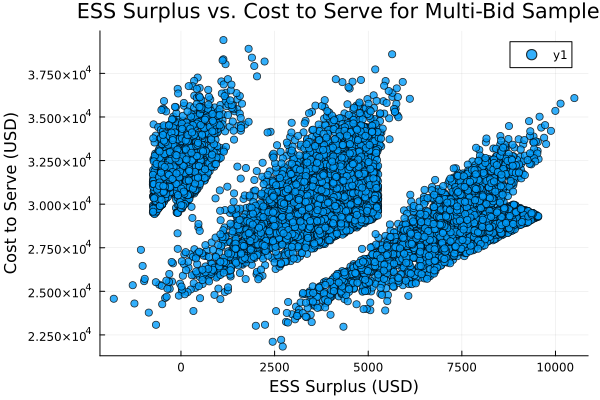

In [6]:
p1 = scatter(
    multi_ess_surplus.multi_bid_ess_surplus,
    multi_cost_by_sample.multi_bid_cost_to_serve,
    xlabel = "ESS Surplus (USD)",
    ylabel = "Cost to Serve (USD)",
    # label = "Multi-bid random samples",
    title = "ESS Surplus vs. Cost to Serve for Multi-Bid Samples",
    legend = :topright,
    alpha = 0.8
)
# hline!(p1, [single_bid_cost_to_serve], label = "Single-bid baseline", linewidth = 3, color = :red)
display(p1)

Interesting grouping: probably related to taking vs. making the price in certain intervals

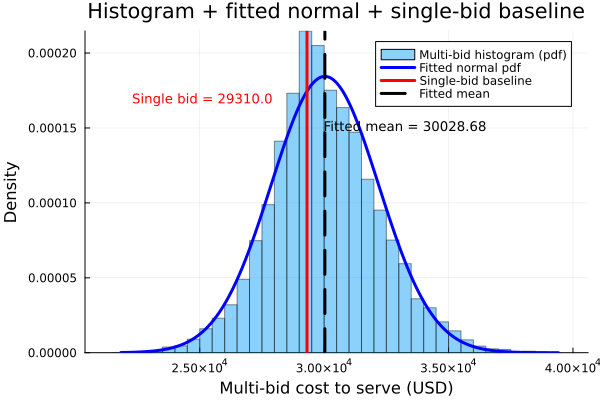

In [ ]:
multi_vals = multi_cost_by_sample.multi_bid_cost_to_serve
mu_hat = mean(multi_vals)
sigma_hat = std(multi_vals)

normal_pdf(x, mu, sigma) = (1 / (sigma * sqrt(2 * pi))) * exp(-0.5 * ((x - mu) / sigma)^2)

x_min = minimum(multi_vals)
x_max = maximum(multi_vals)
x_grid = collect(range(x_min, x_max, length=400))
y_grid = normal_pdf.(x_grid, mu_hat, sigma_hat)

p2 = histogram(
    multi_vals,
    bins = :auto,
    normalize = :pdf,
    xlabel = "Multi-bid cost to serve (USD)",
    ylabel = "Density",
    label = "Multi-bid histogram (pdf)",
    title = "Histogram + fitted normal + single-bid baseline",
    alpha = 0.45
)
plot!(p2, x_grid, y_grid, label = "Fitted normal pdf", linewidth = 3, color = :blue)
vline!(p2, [single_bid_cost_to_serve], label = "Single-bid baseline", linewidth = 3, color = :red)
vline!(p2, [mu_hat], label = "Fitted mean", linewidth = 3, color = :black, linestyle = :dash)

ymax = maximum(y_grid)
annotate!(p2, single_bid_cost_to_serve - 7e3, ymax * 0.92, text("Single bid = $(round(single_bid_cost_to_serve, digits=2))", :red, 9, :left))
annotate!(p2, mu_hat, ymax * 0.82, text("Fitted mean = $(round(mu_hat, digits=2))", :black, 9, :left))

display(p2)

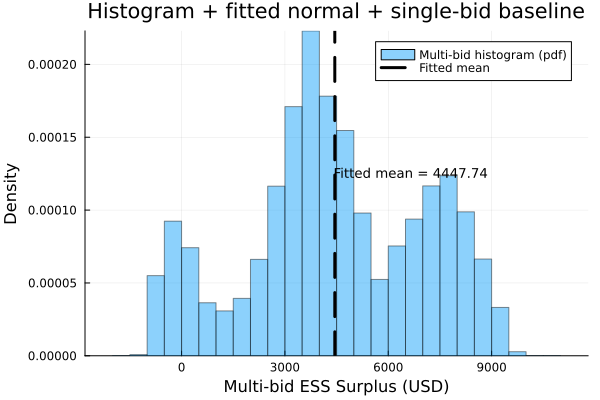

In [11]:
multi_vals = multi_ess_surplus.multi_bid_ess_surplus
mu_hat = mean(multi_vals)
sigma_hat = std(multi_vals)

normal_pdf(x, mu, sigma) = (1 / (sigma * sqrt(2 * pi))) * exp(-0.5 * ((x - mu) / sigma)^2)

x_min = minimum(multi_vals)
x_max = maximum(multi_vals)
x_grid = collect(range(x_min, x_max, length=400))
y_grid = normal_pdf.(x_grid, mu_hat, sigma_hat)

p2 = histogram(
    multi_vals,
    bins = :auto,
    normalize = :pdf,
    xlabel = "Multi-bid ESS Surplus (USD)",
    ylabel = "Density",
    label = "Multi-bid histogram (pdf)",
    title = "Histogram + fitted normal + single-bid baseline",
    alpha = 0.45
)
# plot!(p2, x_grid, y_grid, label = "Fitted normal pdf", linewidth = 3, color = :blue)
# vline!(p2, [single_bid_cost_to_serve], label = "Single-bid baseline", linewidth = 3, color = :red)
vline!(p2, [mu_hat], label = "Fitted mean", linewidth = 3, color = :black, linestyle = :dash)

ymax = maximum(y_grid)
# annotate!(p2, single_bid_cost_to_serve - 7e3, ymax * 0.92, text("Single bid = $(round(single_bid_cost_to_serve, digits=2))", :red, 9, :left))
annotate!(p2, mu_hat, ymax * 0.82, text("Fitted mean = $(round(mu_hat, digits=2))", :black, 9, :left))

display(p2)

In [6]:
summary_df = DataFrame(
    metric = [
        "single_bid_cost_to_serve",
        "fitted_normal_mean",
        "fitted_normal_std",
        "multi_mean",
        "multi_median",
        "multi_min",
        "multi_max",
        "pct_multi_below_single",
        "pct_multi_above_single"
    ],
    value = [
        single_bid_cost_to_serve,
        mu_hat,
        sigma_hat,
        mean(multi_vals),
        median(multi_vals),
        minimum(multi_vals),
        maximum(multi_vals),
        100 * mean(multi_vals .< single_bid_cost_to_serve),
        100 * mean(multi_vals .> single_bid_cost_to_serve)
    ]
)
summary_df

Row,metric,value
,String,Float64
1,single_bid_cost_to_serve,29310.0
2,fitted_normal_mean,30028.7
3,fitted_normal_std,2163.22
4,multi_mean,30028.7
5,multi_median,29863.5
6,multi_min,21830.0
7,multi_max,39412.0
8,pct_multi_below_single,37.97
9,pct_multi_above_single,62.02
